<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/COMPARACION_GENERADORES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Creamos una función para generar números mediante LCG
def LCG_generator(n, seed = 1):
    a = 65539
    c = 0
    m = 2 ** 31
    x = seed
    results = []
    for i in range(n * 3):
        x = (a * x + c) % m
        results.append(x / m)
    return np.array(results).reshape(n, 3)

In [2]:
# Generamos n_points números pseudoaleatorios con cada generador
n_points = 8000 # Entre mayor sea n_points más visibles serán los planos de Marsaglia

# Generamos mediante LCG
LCG_points = LCG_generator(n_points)

# Generamos mediante Mersenne
mersenne_points = np.random.rand(n_points, 3) # np.random.rand utiliza MT19937 por retrocompatibilidad

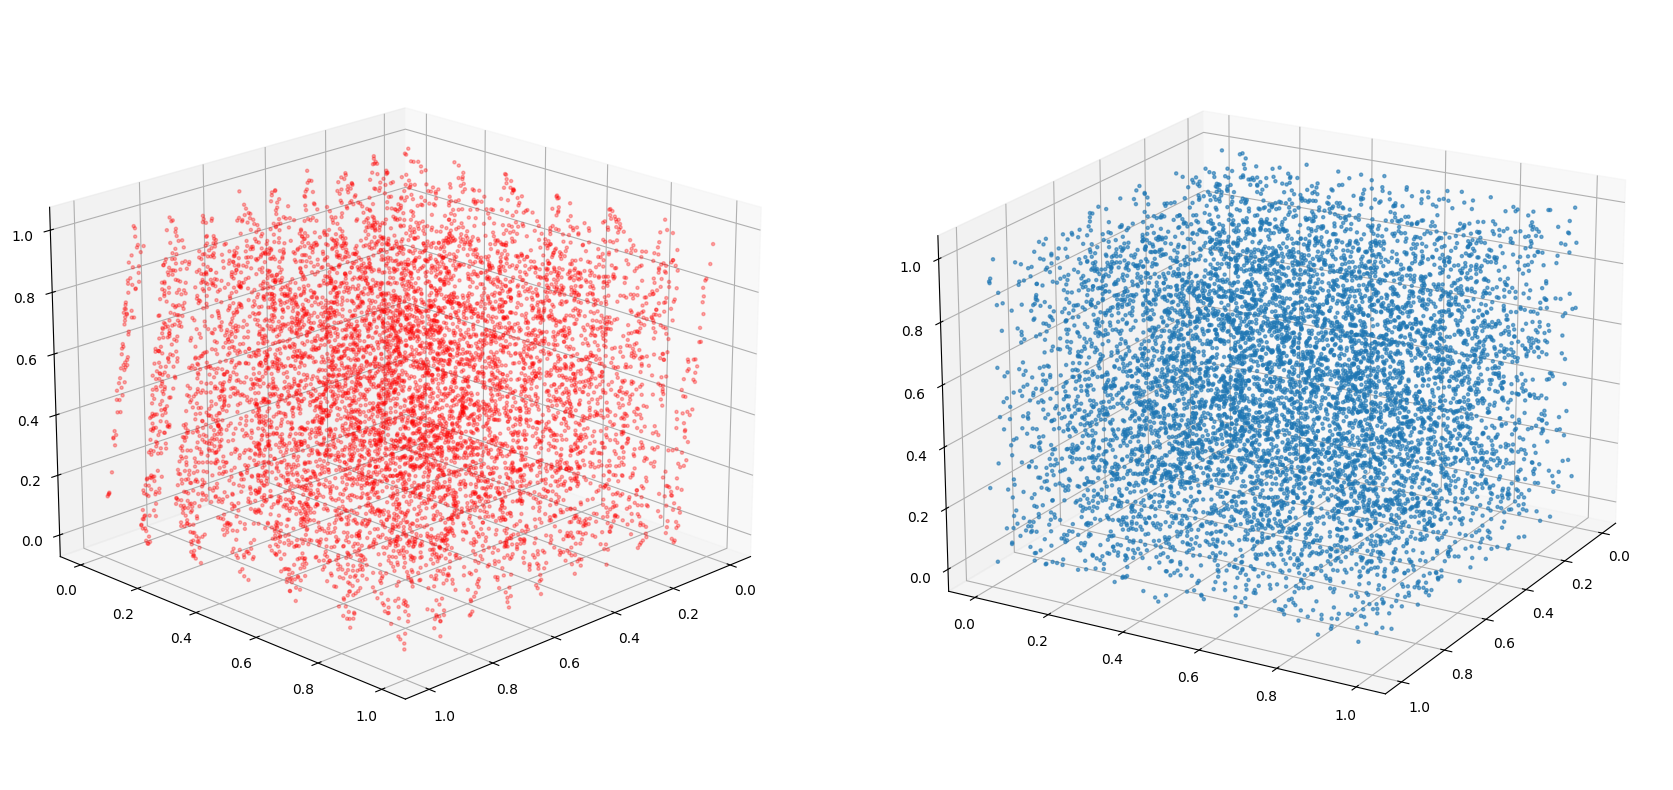

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 8))

# Graficamos los números generados mediante LCG
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(LCG_points[:, 0], LCG_points[:, 1], LCG_points[:, 2], s=5, alpha=0.3, color='red', label='LCG')
ax1.view_init(elev=20, azim=45)

# Graficamos los número generados mediante MT
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(mersenne_points[:, 0], mersenne_points[:, 1], mersenne_points[:, 2], s=5, alpha=0.6, label='MT')
ax2.view_init(elev=20, azim=30)

plt.tight_layout()
plt.savefig('COMPARACION_GENERADORES.pdf', bbox_inches='tight')
plt.show()


In [4]:
# Guardamos la imagen en pdf
from google.colab import files
files.download("COMPARACION_GENERADORES.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>